# 03. Weighted BatchNorm CNN for Melanoma Classification

**Objective**  
Extend the weighted CNN baseline by adding batch normalization after each convolutional layer. This notebook tests whether batch normalization improves training stability and overall performance while still using class-weighted loss to emphasize melanoma detection.

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Block 1 | `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` |
| Block 2 | `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` |
| Block 3 | `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` |
| Classifier | `Flatten -> Linear(...) -> ReLU -> Dropout -> Linear(..., 1)` |

**Hypothesis**  
Compared with the weighted baseline in Notebook 02, adding batch normalization should make optimization more stable, improve feature learning, and potentially increase validation and test performance without changing the overall CNN design too drastically.


### 1. Setup and Imports

This section loads the project modules, trainer utilities, and shared evaluation helpers, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.cnn_batchnorm import BatchNormCNN
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


### 2. Data Split and Weighted-Loss Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
This experiment replaces the baseline CNN with `BatchNormCNN`, while keeping weighted BCE loss to address class imbalance:

- `BatchNormCNN` as the feature extractor and classifier
- `BCEWithLogitsLoss(pos_weight=...)` to penalize missed melanoma more strongly
- `Adam` with learning rate `1e-3`
- Batch size `32` and image size `224 x 224`

The positive-class weight is computed as:

`pos_weight = number_of_nevus / number_of_melanoma`

This keeps the weighted-loss setup consistent with the earlier experiment while isolating the effect of batch normalization.


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / "data_new/splits/train.csv"),
    val_csv=str(ROOT / "data_new/splits/val.csv"),
    test_csv=str(ROOT / "data_new/splits/test.csv"),
    image_dir=str(ROOT / "data_new/images/train"),
    test_image_dir=str(ROOT / "data_new/images/test"),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv(ROOT / "data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()
num_nevus = (train_df["label"] == 0).sum()

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32, device=device)

print(f"Melanoma samples: {num_melanoma}")
print(f"Nevus samples: {num_nevus}")
print(f"pos_weight: {pos_weight.item():.4f}")

model = BatchNormCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Melanoma samples: 877
Nevus samples: 7114
pos_weight: 8.1117


### 3. Train the Weighted BatchNorm Model

The model is trained for `20` epochs using the BatchNorm CNN with weighted BCE loss. Training and validation metrics are stored as lists of dictionaries so they can be passed directly into the shared plotting function later. The checkpoint with the highest validation AUC is saved.


In [3]:
num_epochs = 20

best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/cnn_batchnorm_weighted.pth')
        print(f"  -> Saved best model (val AUC: {best_val_auc:.4f})")


Epoch [1/20]
  Train | Loss: 4.3960, Bal Acc: 0.6608, Recall: 0.7560, F2: 0.4565, AUC: 0.6924
  Val   | Loss: 1.0193, Bal Acc: 0.7107, Recall: 0.8263, F2: 0.5233, AUC: 0.7967
  -> Saved best model (val AUC: 0.7967)


Epoch [2/20]
  Train | Loss: 1.0024, Bal Acc: 0.7246, Recall: 0.8347, F2: 0.5242, AUC: 0.7893
  Val   | Loss: 0.9316, Bal Acc: 0.7335, Recall: 0.8517, F2: 0.5483, AUC: 0.8165
  -> Saved best model (val AUC: 0.8165)


Epoch [3/20]
  Train | Loss: 0.9947, Bal Acc: 0.7320, Recall: 0.8438, F2: 0.5324, AUC: 0.7943
  Val   | Loss: 0.9436, Bal Acc: 0.7243, Recall: 0.8093, F2: 0.5365, AUC: 0.8162


Epoch [4/20]
  Train | Loss: 0.9953, Bal Acc: 0.7317, Recall: 0.8369, F2: 0.5319, AUC: 0.7929
  Val   | Loss: 0.9546, Bal Acc: 0.7332, Recall: 0.8898, F2: 0.5495, AUC: 0.8119


Epoch [5/20]
  Train | Loss: 1.0184, Bal Acc: 0.7308, Recall: 0.8255, F2: 0.5307, AUC: 0.7905
  Val   | Loss: 1.0033, Bal Acc: 0.6915, Recall: 0.9534, F2: 0.5139, AUC: 0.8136


...

Epoch [16/20]
  Train | Loss: 0.9443, Bal Acc: 0.7519, Recall: 0.7469, F2: 0.5558, AUC: 0.8317
  Val   | Loss: 0.8705, Bal Acc: 0.7645, Recall: 0.8008, F2: 0.5837, AUC: 0.8501


Epoch [17/20]
  Train | Loss: 0.8963, Bal Acc: 0.7633, Recall: 0.7605, F2: 0.5711, AUC: 0.8423
  Val   | Loss: 0.9509, Bal Acc: 0.7652, Recall: 0.8347, F2: 0.5846, AUC: 0.8495


Epoch [18/20]
  Train | Loss: 1.0711, Bal Acc: 0.7391, Recall: 0.7298, F2: 0.5390, AUC: 0.8073
  Val   | Loss: 1.0045, Bal Acc: 0.7572, Recall: 0.7415, F2: 0.5738, AUC: 0.8403


Epoch [19/20]
  Train | Loss: 0.9685, Bal Acc: 0.7689, Recall: 0.7434, F2: 0.5798, AUC: 0.8341
  Val   | Loss: 0.9489, Bal Acc: 0.7634, Recall: 0.7712, F2: 0.5822, AUC: 0.8310


Epoch [20/20]
  Train | Loss: 0.9135, Bal Acc: 0.7641, Recall: 0.7377, F2: 0.5731, AUC: 0.8454
  Val   | Loss: 0.8875, Bal Acc: 0.7677, Recall: 0.8771, F2: 0.5874, AUC: 0.8601
  -> Saved best model (val AUC: 0.8601)


### 4. Plot Training Curves

This notebook uses the shared evaluation utility to render the standard 2 × 2 dashboard: Loss, Balanced Accuracy, Recall, and F2. This keeps the BatchNorm experiment directly comparable with the earlier CNN notebooks.


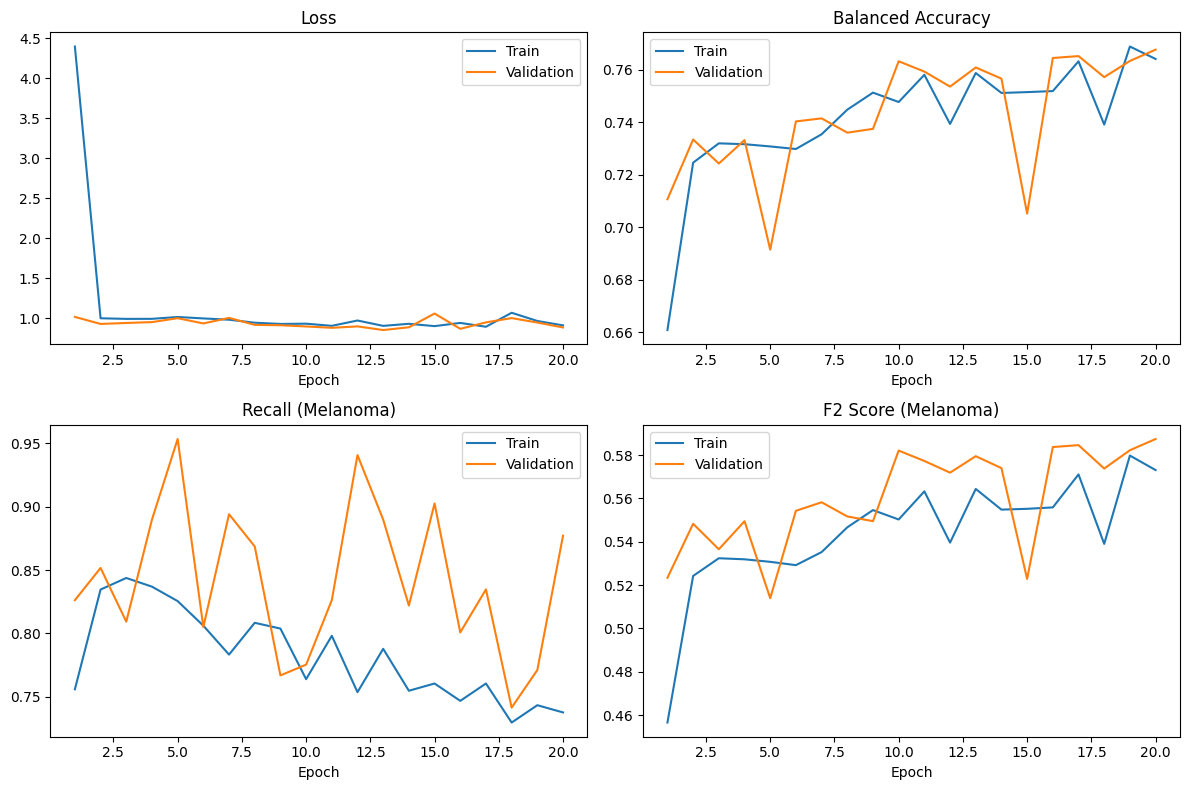

In [4]:
plot_training_curves(train_history, val_history)

### 5. Tune the Classification Threshold on the Validation Set

The loss is weighted during training, but the classification threshold still needs to be chosen separately.  
This step reloads the best saved checkpoint and finds the probability threshold that maximizes **F2 score** on the validation set.


In [5]:
model.load_state_dict(torch.load(ROOT / 'models/cnn_batchnorm_weighted.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")


Best threshold: 0.65 | Val F2: 0.5978
Best validation threshold: 0.65
Best validation F2: 0.5978


### 6. Evaluate on the Test Set

The best BatchNorm-weighted checkpoint is evaluated on the held-out test set using the threshold selected on the validation set.  
The shared evaluation utility reports AUC-ROC, balanced accuracy, F2 score, a classification report, and visual diagnostics such as the confusion matrix and ROC curve.


Threshold:          0.65
AUC-ROC:            0.8520
Balanced Accuracy:  0.7735
F2 Score:           0.5900

              precision    recall  f1-score   support

Non-Melanoma     0.9657    0.7575    0.8490      1340
    Melanoma     0.2935    0.7895    0.4279       171

    accuracy                         0.7611      1511
   macro avg     0.6296    0.7735    0.6385      1511
weighted avg     0.8897    0.7611    0.8014      1511



/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


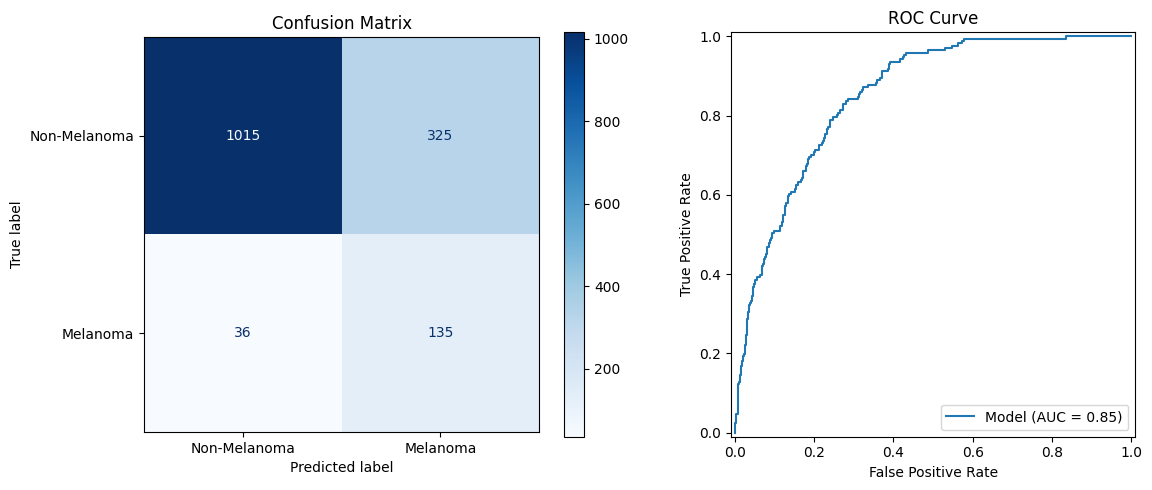

In [6]:
evaluate_model(model, test_loader, device, threshold=best_threshold)

### Results Summary (BatchNorm CNN)

**Performance**
- AUC: 0.8520 (slightly improved)
- Balanced Accuracy: 0.7735 (improved)
- F2 Score: 0.5900 (improved)
- Best threshold: 0.65

**Class-wise Behavior**
- Melanoma recall: 0.7895 → strong improvement in sensitivity
- Melanoma precision: 0.2935 → still low (many false positives)
- Non-melanoma accuracy remains high

**Training Behavior**
- Validation AUC steadily improves to ~0.86
- Training is more stable compared to baseline
- Less fluctuation across epochs → better convergence
- Both losses are relatively flat, not continuously decreasing

**Conclusion**
- BatchNorm improves feature learning and training stability
- Leads to better overall metrics (AUC, F2, balanced accuracy)
- However, precision remains low, indicating limited class separation
- The model is stable and generalizing well, but not powerful enough to reduce error further.